# Sampling the real O96 decoder GMMs

## Metrics

N = 40320, K = 4, |E| = 162406
stratum cell counts: {'global': 40320, 'lat_polar': 6808, 'lat_mid': 15912, 'lat_tropics': 17600, 'bimodal': 604, 'unimodal': 39716, 'keff_gt_1p5': 12081}
timings (s): {'knn_graph_s': 0.558, 'anchors_s': 0.022, 'mode_extraction_s': 3.098, 'm1_sweep_s': 37.482, 'm4_sweep_s': 35.008, 'icm_s_per_sweep': 1.094, 'scores_s': 0.979, 'variograms_s': 0.083}


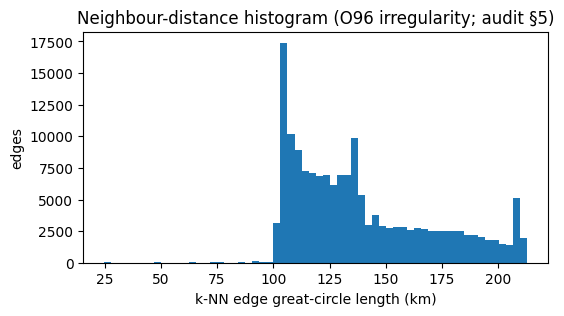

In [1]:
import csv, json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "sampler_research" / "src"))

from sampler_research.io import load_real_marginal
from sampler_research.phase4_eval import select_lambda_star, STRATUM_ORDER

RUN_DIR = PROJECT_ROOT / "outputs" / "runs" / "phase_4_real"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

data = load_real_marginal(PROJECT_ROOT / "outputs" / "data" / "phase_4_real_2t.npz")
masks = dict(np.load(RUN_DIR / "masks.npz"))
sweep = dict(np.load(RUN_DIR / "method1_sweep.npz"))
star = json.loads((RUN_DIR / "lambda_star.json").read_text())
probes = json.loads((RUN_DIR / "robustness_probes.json").read_text())
with open(RUN_DIR / "scores.csv") as fh:
    rows = list(csv.DictReader(fh))
timings = json.loads((RUN_DIR / "timings.json").read_text())

print(f"N = {data['pi'].shape[0]}, K = {data['pi'].shape[1]}, |E| = {len(masks['edges'])}")
print("stratum cell counts:", {s: int(masks[s].sum()) for s in STRATUM_ORDER})
print("timings (s):", timings)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(masks["edge_arc_km"], bins=60)
ax.set_xlabel("k-NN edge great-circle length (km)")
ax.set_ylabel("edges")
ax.set_title("Neighbour-distance histogram (O96 irregularity; audit §5)")
plt.show()

## Figure 1 — global fields

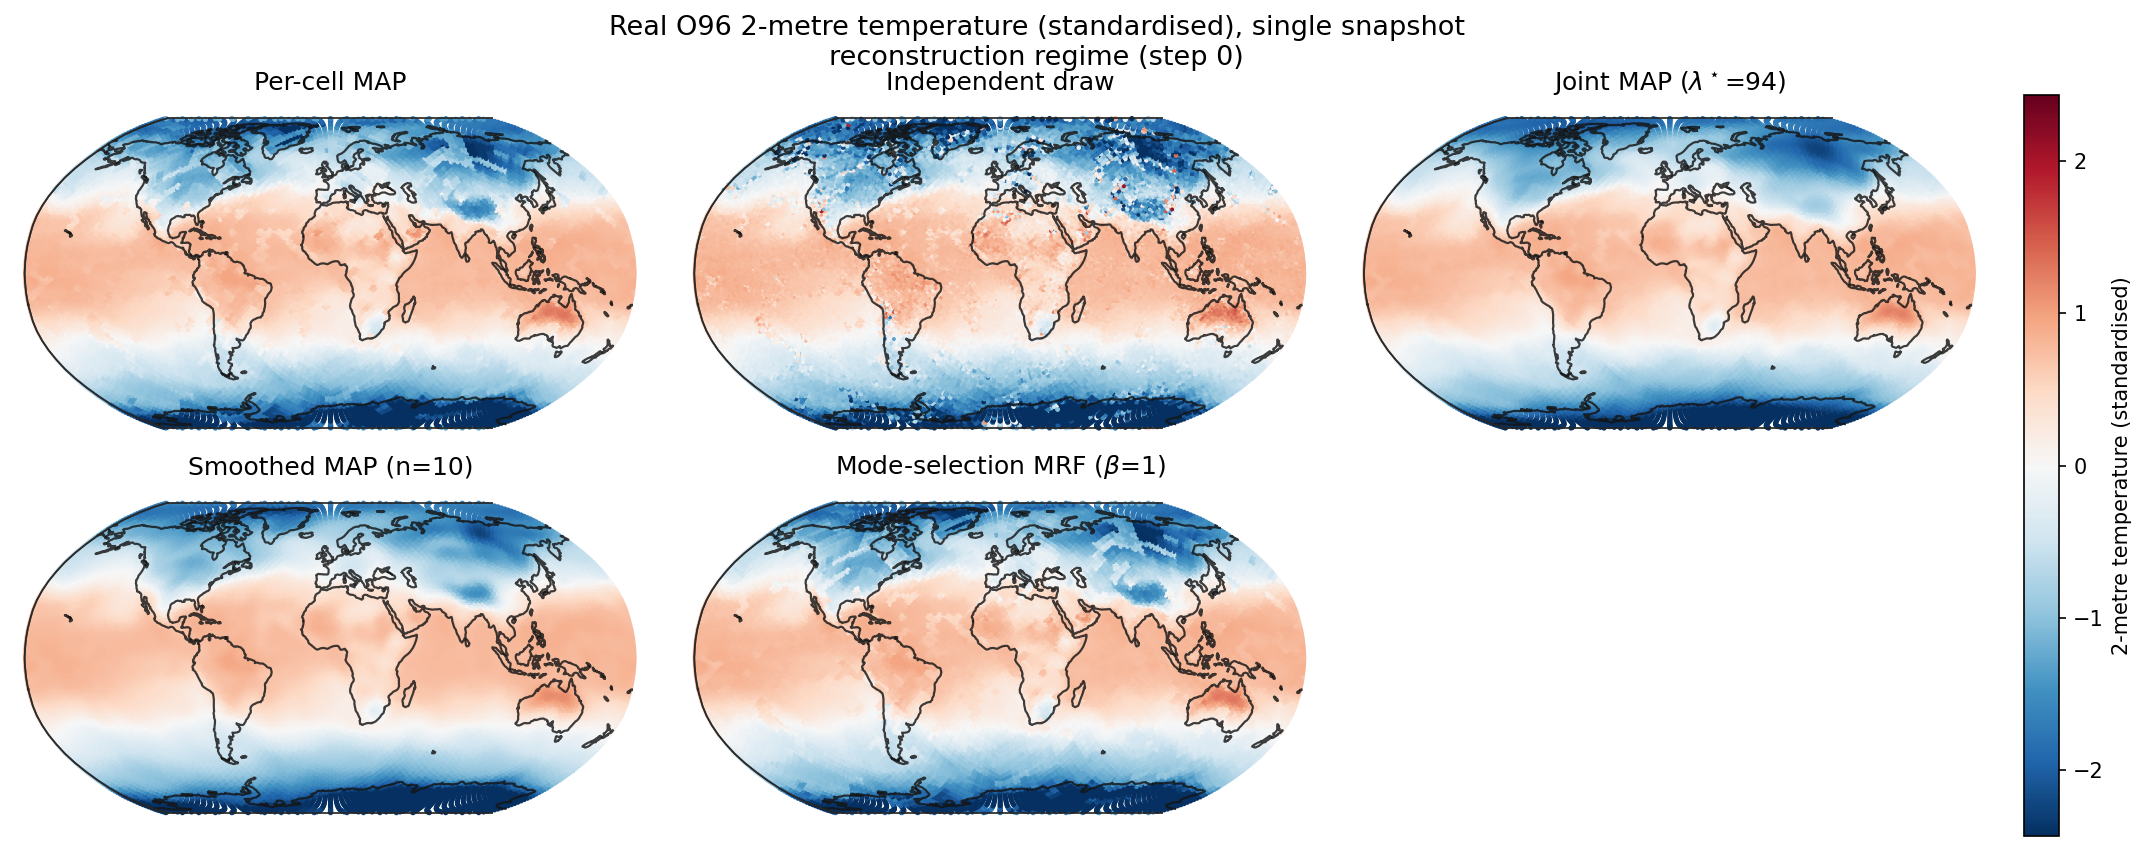

In [2]:
display(Image(str(FIG_DIR / "recon/maps.png"), width=1100))

## Full results table

In [3]:
def fmt(r, key, nd=4):
    return f"{float(r[key]):.{nd}f}"

print(f"{'name':22s} {'param':>9s} {'NLL/N':>8s} {'R~':>9s} {'S_edge':>9s} "
      f"{'dNLL mean':>9s} {'>0.125':>7s} {'wrap':>5s}")
for r in rows:
    rt = "collapsed" if r["variance_collapsed"] == "True" else fmt(r, "r_tilde", 5)
    print(f"{r['name']:22s} {r['param']:>9s} {fmt(r,'nll_over_n'):>8s} {rt:>9s} "
          f"{fmt(r,'s_edge',5):>9s} {fmt(r,'dnll_mean'):>9s} "
          f"{fmt(r,'dnll_frac_gt_0p125'):>7s} {fmt(r,'wrap_seam_ratio',2):>5s}")

name                       param    NLL/N        R~    S_edge dNLL mean  >0.125  wrap
mode_map                          -1.6717   0.02374   0.01892    0.0041  0.0030  0.81
mixture_mean                      -1.6639   0.02015   0.01628    0.0119  0.0212  0.87
iid_seed0                      0  -1.1357   0.15025   0.13023    0.5402  0.6273  0.44
iid_seed1                      1  -1.1352   0.15249   0.13261    0.5406  0.6273  0.52
iid_seed2                      2  -1.1404   0.14470   0.12493    0.5354  0.6254  0.56
smoothed_map_n5                5  -1.4457   0.00399   0.00308    0.2302  0.3668  1.04
smoothed_map_n10              10  -1.3326   0.00303   0.00231    0.3433  0.4661  1.22
smoothed_map_n20              20  -1.1352   0.00238   0.00177    0.5406  0.5648  1.36
m1_lam0                        0  -1.6758   0.02265   0.01809    0.0000  0.0001  0.87
m1_lam0.5                    0.5  -1.6746   0.01367   0.01106    0.0012  0.0016  1.27
m1_lam2                        2  -1.6709   0.00914   

## Figure 2 — Pareto plane + smear tail

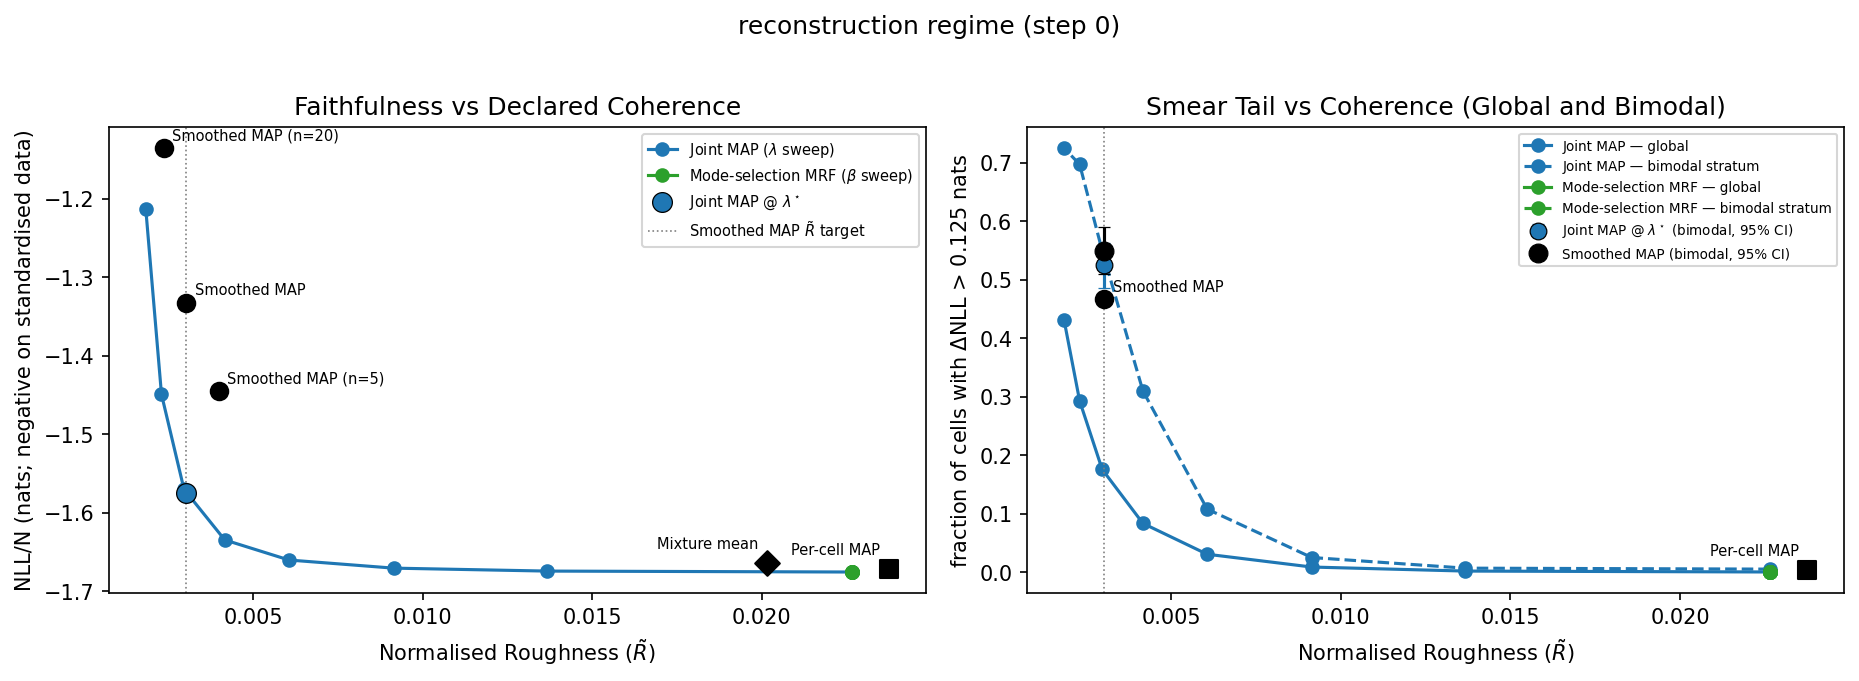

In [4]:
display(Image(str(FIG_DIR / "recon/pareto_smear.png"), width=1100))

## Stratified results (headline fields)

In [5]:
headline = ["mode_map", "iid_seed0", "smoothed_map_n10", "m1_star",
            "m1_star_half", "m1_star_double", "m4_beta1"]
print(f"{'name':18s} {'NLL/N':>8s} {'NLL/N bi':>9s} {'>0.125':>7s} {'>0.125 bi':>9s} "
      f"{'>0.5':>6s} {'>0.5 bi':>8s} {'p95':>6s} {'p95 bi':>7s} "
      f"{'>0.125 polar':>12s} {'>0.125 tropics':>14s}")
for name in headline:
    r = next((x for x in rows if x["name"] == name), None)
    if r is None:
        continue
    print(f"{name:18s} {fmt(r,'nll_over_n'):>8s} {fmt(r,'nll_over_n__bimodal'):>9s} "
          f"{fmt(r,'dnll_frac_gt_0p125'):>7s} {fmt(r,'dnll_frac_gt_0p125__bimodal'):>9s} "
          f"{fmt(r,'dnll_frac_gt_0p5',3):>6s} {fmt(r,'dnll_frac_gt_0p5__bimodal',3):>8s} "
          f"{fmt(r,'dnll_p95',2):>6s} {fmt(r,'dnll_p95__bimodal',2):>7s} "
          f"{fmt(r,'dnll_frac_gt_0p125__lat_polar'):>12s} "
          f"{fmt(r,'dnll_frac_gt_0p125__lat_tropics'):>14s}")

name                  NLL/N  NLL/N bi  >0.125 >0.125 bi   >0.5  >0.5 bi    p95  p95 bi >0.125 polar >0.125 tropics
mode_map            -1.6717   -0.6772  0.0030    0.0215  0.000    0.000   0.02    0.08       0.0073         0.0013
iid_seed0           -1.1357   -0.1245  0.6273    0.6358  0.331    0.359   2.09    1.98       0.6372         0.6249
smoothed_map_n10    -1.3326   -0.3261  0.4661    0.5497  0.194    0.210   1.52    1.28       0.5308         0.3835
m1_star             -1.5750   -0.3816  0.1694    0.5248  0.043    0.185   0.44    1.23       0.3844         0.0723
m1_star_half        -1.6189   -0.5111  0.1128    0.3725  0.023    0.089   0.29    0.70       0.2916         0.0378
m1_star_double      -1.5036   -0.1705  0.2407    0.6672  0.076    0.311   0.76    1.85       0.4841         0.1179
m4_beta1            -1.6758   -0.6894  0.0000    0.0000  0.000    0.000   0.00    0.00       0.0000         0.0000


## λ\* selection

In [6]:
sel = select_lambda_star(
    sweep["lambdas"], sweep["r_tilde"], sweep["variance_collapsed"],
    star["target_r_tilde"], valid=sweep["warm_start_sane"],
)
assert np.isclose(sel.lambda_star, star["lambda_star"]), "lambda_star.json mismatch"
print(f"lambda* = {sel.lambda_star:.2f} (target R~ {sel.target_r_tilde:.5f}, "
      f"bracketed={sel.bracketed}, clauses={sel.clauses or 'none'})")
print(f"target anchor: {star['target_anchor']}")
print()
print(f"{'row':8s} {'lambda':>9s} {'NLL/N':>9s} {'R~':>9s} {'collapsed':>9s} "
      f"{'restart NLL/N range':>22s}")
for tag in ("half", "star", "double"):
    s = star["sensitivity"][tag]
    rng_ = s["restart_nll_max"] - s["restart_nll_min"]
    print(f"{tag:8s} {s['lambda']:>9.2f} {s['nll_over_n']:>9.4f} {s['r_tilde']:>9.5f} "
          f"{str(s['variance_collapsed']):>9s} {rng_:>22.2e}")
print()
print("No variance-collapse flag fired anywhere on this grid (incl. 2*lambda*);")
print("the expected strong-lambda failure (collapse, not smear -- toy verdict)")
print("has not been reached by lambda = 1000 on this data.")
print()
ss = probes["lambda_star_seed_stability"]
vals = [ss["base_lambda_star"]] + [o["lambda_star"] for o in ss["offsets"].values()]
print(f"Restart-seed stability (robustness_probes.json): re-solving the bracketing")
print(f"rows (lambda 30/100, production settings) at seed offsets +1000/+2000")
print(f"re-interpolates lambda* to {min(vals):.2f}-{max(vals):.2f} -- "
      f"the operating point is seed-stable.")

lambda* = 93.74 (target R~ 0.00303, bracketed=True, clauses=none)
target anchor: smoothed_map_n10

row         lambda     NLL/N        R~ collapsed    restart NLL/N range
half         46.87   -1.6189   0.00369     False               8.57e-04
star         93.74   -1.5750   0.00302     False               1.93e-04
double      187.49   -1.5036   0.00254     False               2.39e-03

No variance-collapse flag fired anywhere on this grid (incl. 2*lambda*);
the expected strong-lambda failure (collapse, not smear -- toy verdict)
has not been reached by lambda = 1000 on this data.

Restart-seed stability (robustness_probes.json): re-solving the bracketing
rows (lambda 30/100, production settings) at seed offsets +1000/+2000
re-interpolates lambda* to 93.72-93.74 -- the operating point is seed-stable.


## Figure 3 — bimodal-mask enrichment + ΔNLL map

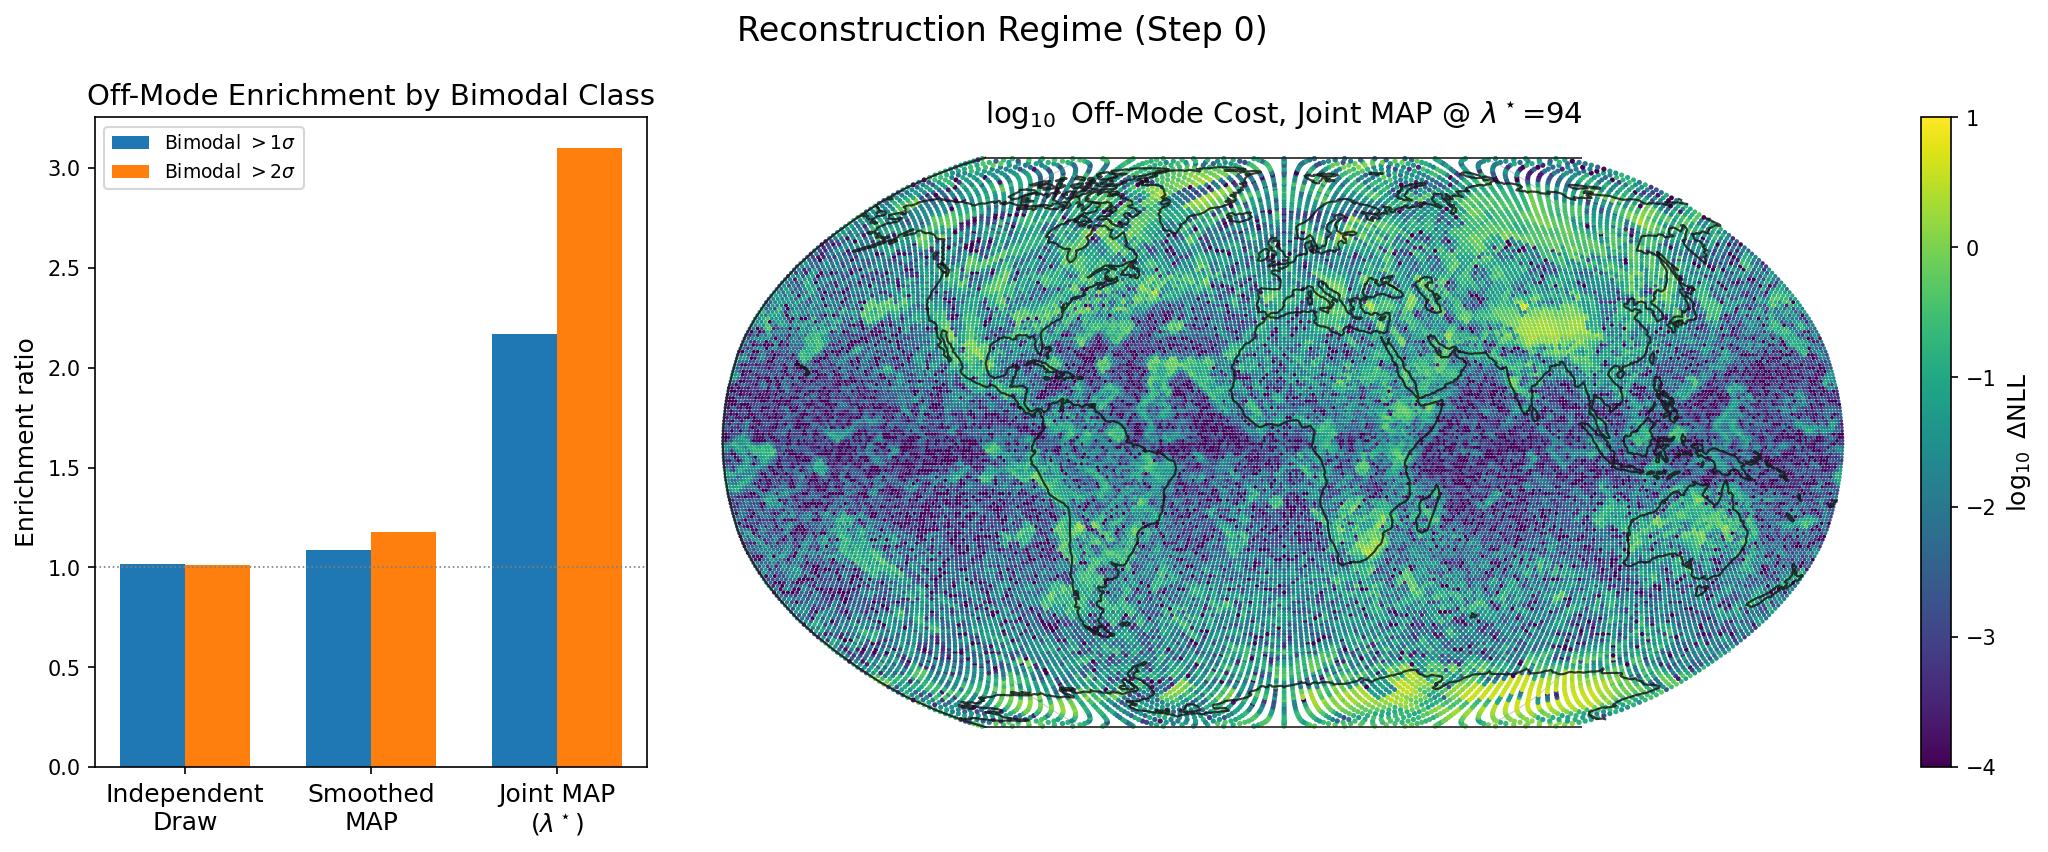

In [7]:
display(Image(str(FIG_DIR / "recon/bimodal_enrichment.png"), width=1100))

## Mode-selection MRF on near-one-hot data

In [8]:
m4 = dict(np.load(RUN_DIR / "method4_sweep.npz"))
print(f"{'beta':>8s} {'NLL/N':>9s} {'R~':>9s} {'max sweeps':>10s}")
for b, nll, rt, ns in zip(m4["betas"], m4["nll_over_n"], m4["r_tilde"], m4["n_sweeps_max"]):
    print(f"{b:>8.4g} {nll:>9.4f} {rt:>9.5f} {ns:>10d}")
print()
bs = probes["m4_beta_scale"]
gap = bs["unary_gap_nats"]
b10, b100 = bs["betas"]["10"], bs["betas"]["100"]


    beta     NLL/N        R~ max sweeps
    0.01   -1.6758   0.02265          2
 0.01931   -1.6758   0.02265          3
 0.03728   -1.6758   0.02265          3
 0.07197   -1.6758   0.02265          3
  0.1389   -1.6758   0.02265          3
  0.2683   -1.6758   0.02265          3
  0.5179   -1.6758   0.02265          3
       1   -1.6758   0.02265          3



## Robustness (persisted probes)

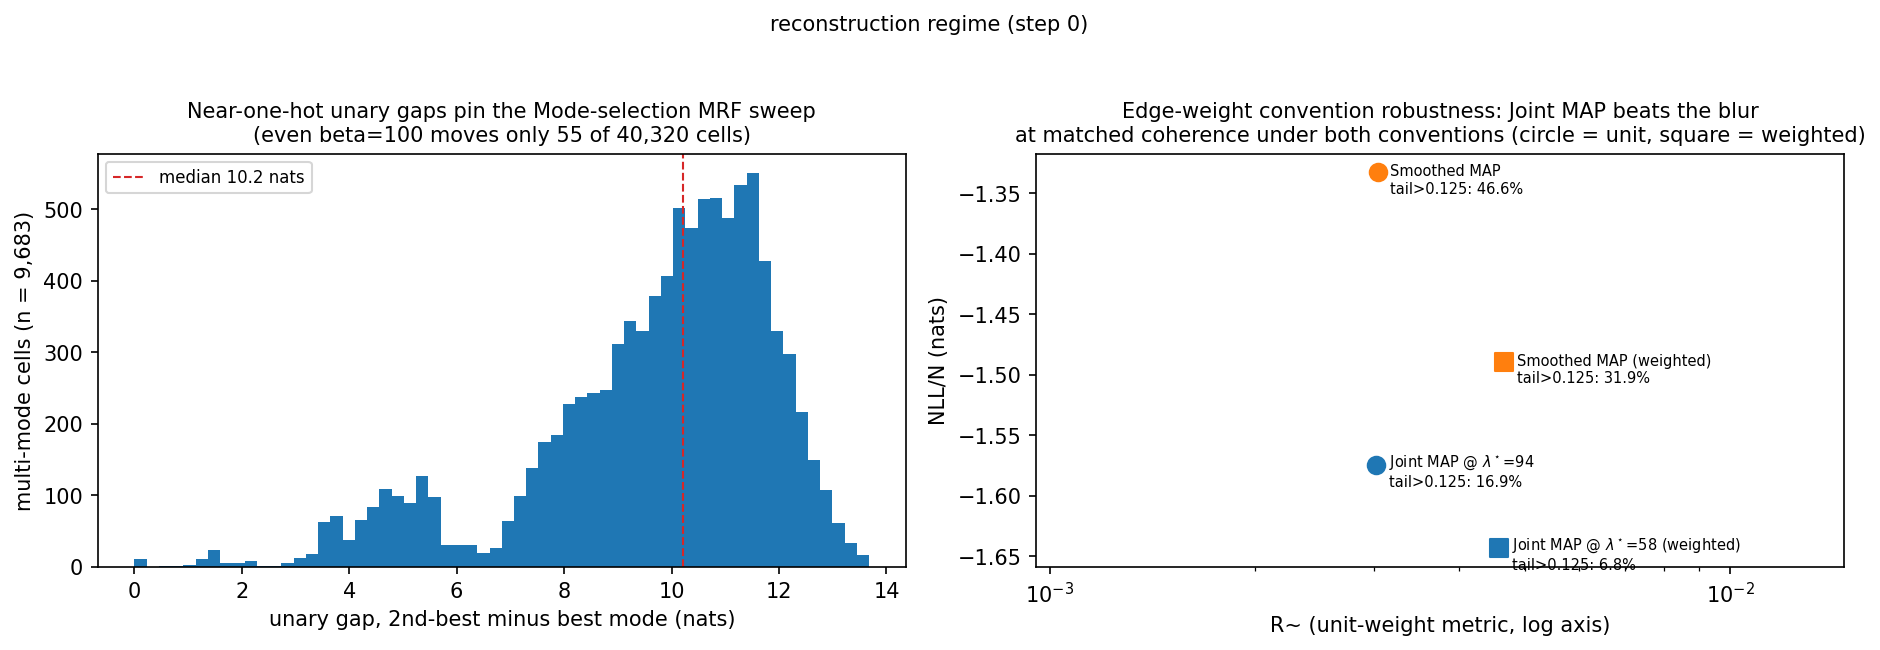

In [9]:
display(Image(str(FIG_DIR / "recon/robustness.png"), width=1100))

bl = probes["blur_stability"]
ws = probes["iid_wrap_seam"]
wg = probes["weighted_graph"]
iid_wraps = [float(r["wrap_seam_ratio"]) for r in rows if r["name"].startswith("iid_seed")]